# Defect Detection — Statistical Process Control (SPC)
### Detectron AI · Module 13

This notebook implements real **Statistical Process Control** — the same methodology
used on factory-floor quality control charts — including control limits (UCL/LCL),
process capability index (**Cpk**), and a supervised **Random Forest** model trained
to predict defects from multiple correlated process variables.


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

np.random.seed(21)


## 1. Simulate a production batch — single dimension (SPC)

In [2]:
target, tolerance = 50.0, 4.0
n = 40
measurements = target + np.random.normal(0, 1.1, n)
# inject a few process drift defects
defect_idx = np.random.choice(n, 4, replace=False)
measurements[defect_idx] += np.random.choice([-1,1], 4) * np.random.uniform(5, 9, 4)

mean, sigma = measurements.mean(), measurements.std()
ucl, lcl = mean + 3*sigma, mean - 3*sigma
spec_upper, spec_lower = target + tolerance, target - tolerance

print(f"Process mean: {mean:.2f}  sigma: {sigma:.2f}")
print(f"Control limits: UCL={ucl:.2f}  LCL={lcl:.2f}")
print(f"Spec limits: [{spec_lower:.2f}, {spec_upper:.2f}]")


Process mean: 50.62  sigma: 2.20
Control limits: UCL=57.22  LCL=44.01
Spec limits: [46.00, 54.00]


## 2. Process Capability Index (Cpk)

Cpk >= 1.33 is the standard manufacturing threshold for a 'capable' process.

In [3]:
cpk_upper = (spec_upper - mean) / (3 * sigma)
cpk_lower = (mean - spec_lower) / (3 * sigma)
cpk = min(cpk_upper, cpk_lower)
print(f"Cpk = {cpk:.2f} -> {'CAPABLE' if cpk >= 1.33 else 'NOT CAPABLE'}")


Cpk = 0.51 -> NOT CAPABLE


## 3. Control chart visualization

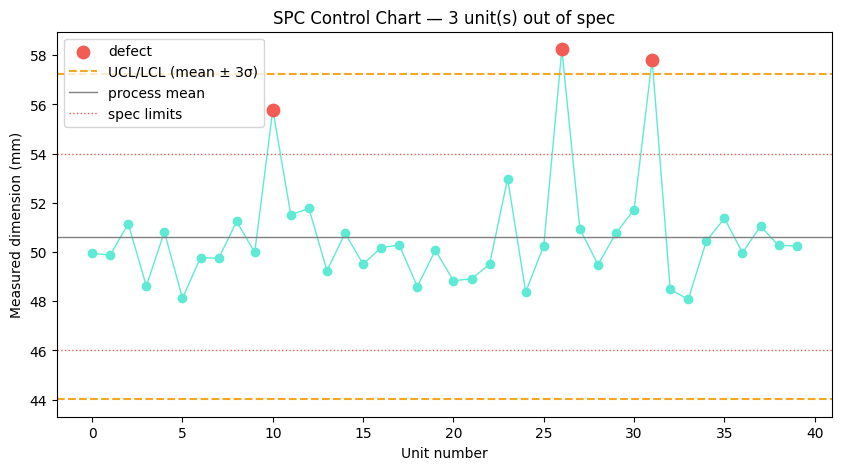

In [4]:
defects = (measurements > spec_upper) | (measurements < spec_lower)

plt.figure(figsize=(10,5))
plt.plot(measurements, marker='o', color="#5EEAD4", linewidth=1)
plt.scatter(np.where(defects)[0], measurements[defects], color="#F25C54", s=80, zorder=5, label="defect")
plt.axhline(ucl, color="#F5A623", linestyle="--", label="UCL/LCL (mean ± 3σ)")
plt.axhline(lcl, color="#F5A623", linestyle="--")
plt.axhline(mean, color="gray", linestyle="-", linewidth=1, label="process mean")
plt.axhline(spec_upper, color="#F25C54", linestyle=":", linewidth=1, label="spec limits")
plt.axhline(spec_lower, color="#F25C54", linestyle=":", linewidth=1)
plt.legend(); plt.title(f"SPC Control Chart — {defects.sum()} unit(s) out of spec")
plt.xlabel("Unit number"); plt.ylabel("Measured dimension (mm)")
plt.show()


## 4. Multivariate defect prediction (Random Forest)

Real manufacturing QC often monitors multiple correlated process variables (temperature, pressure, speed) rather than a single dimension.

In [5]:
n_units = 600
temp = np.random.normal(180, 5, n_units)
pressure = np.random.normal(40, 3, n_units)
speed = np.random.normal(120, 8, n_units)
material_batch_age = np.random.uniform(0, 30, n_units)

defect_logit = (
    0.15*(temp-180) - 0.1*(pressure-40) + 0.05*(speed-120) +
    0.08*(material_batch_age-15) - 2.0
)
defect_prob = 1 / (1 + np.exp(-defect_logit))
is_defect = (np.random.rand(n_units) < defect_prob).astype(int)

df = pd.DataFrame({
    "temperature": temp, "pressure": pressure, "speed": speed,
    "material_batch_age": material_batch_age, "defect": is_defect
})
print(df["defect"].value_counts(normalize=True).round(3))


defect
0    0.847
1    0.153
Name: proportion, dtype: float64


In [6]:
features = ["temperature", "pressure", "speed", "material_batch_age"]
X, y = df[features], df["defect"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=150, max_depth=5, class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print(classification_report(y_test, pred, target_names=["good", "defect"]))


              precision    recall  f1-score   support

        good       0.88      0.86      0.87       127
      defect       0.31      0.35      0.33        23

    accuracy                           0.78       150
   macro avg       0.59      0.60      0.60       150
weighted avg       0.79      0.78      0.79       150



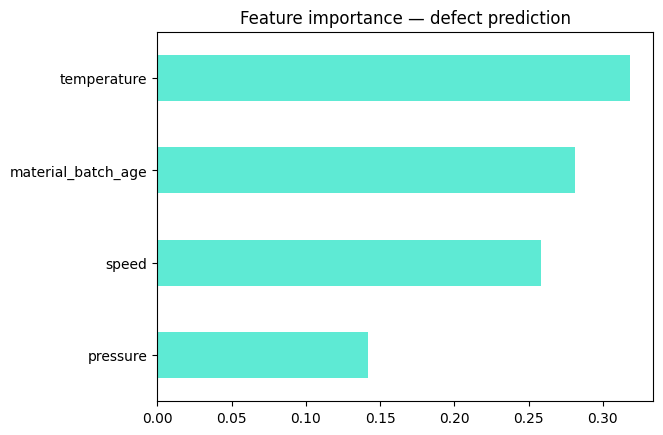

In [7]:
importances = pd.Series(clf.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", color="#5EEAD4")
plt.title("Feature importance — defect prediction")
plt.show()


## Notes

- SPC control charts (UCL/LCL at mean ± 3σ) are the long-standing standard for monitoring
  a single process variable on the factory floor — the live web demo implements this
  exact calculation directly in JavaScript with an interactive control chart.
- The Random Forest model demonstrates how multivariate process monitoring (multiple
  correlated sensors) can predict defects earlier than a single-variable control chart,
  which is increasingly common in modern Industry 4.0 manufacturing lines.
